# Documentation
## How to use this notebook

This notebook is structured as a step-by-step guide to the quantum circuit optimiser. 
Each section introduces a key component of the optimisation pipeline, along with 
examples demonstrating how to use it in practice. It is recommended to follow the sections in order, as later components build on earlier ones.

## Contents:
- [Converting between a circuit and a ZX diagram](#converting-between-a-circuit-and-a-zx-diagram)
- [Getting circuit metrics](#getting-circuit-metrics)
- [Designing a cost function](#designing-a-cost-function)
- [Designing the hardware](#designing-the-hardware-map)
- [Running the optimiser](#running-the-optimiser)

# Converting between a circuit and a ZX Diagram
This section demonstrates how quantum circuits are translated into ZX diagrams using PyZX, and how diagrams can be converted back into equivalent circuit representations.

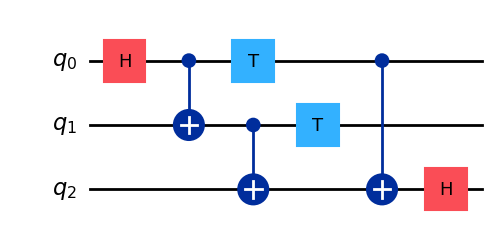

In [1]:
from qiskit import QuantumCircuit #Import qiskit to create our circuits

#Lets begin by constructing a quantum circuit using qiskit
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.t(0)
qc.t(1)
qc.cx(0, 2)
qc.h(2)

qc.draw('mpl') #Display the circuit 

## From a circuit to a diagram

In [2]:
from quantum_optimiser import integration #Import the integration file from the library
import pyzx #Import pyzx to display the diagram

# We can convert it to a ZX diagram as so:
diagram = integration.qiskit_to_pyzx(qc)
pyzx.draw(diagram, labels = "True") # Display the diagram

## Applying a ZX rewrite rule
Before we convert the diagram back to a circuit, lets apply a rewrite rule:

In [3]:
from quantum_optimiser.multimetric import rewrite #Import the rewrite file from the library

#First lets see what rewrite rules are applicable on our diagram
for i in range (len(diagram.vertices())):
    print(i,rewrite.get_applicable_rules(diagram,i))
    
#It seems we can remove an identity at vertex 12
new_diagram = rewrite.try_remove_id(diagram,12)

#Lets take a look at what that did to the diagram
pyzx.draw(new_diagram, labels="True")

0 ['pivot', 'insert_hadamard_pair']
1 ['pivot', 'insert_hadamard_pair']
2 ['pivot', 'insert_hadamard_pair']
3 ['remove_id', 'color_change', 'fuse', 'pivot', 'split_spider', 'insert_hadamard_pair']
4 ['color_change', 'pivot', 'split_spider', 'insert_hadamard_pair']
5 ['color_change', 'fuse', 'pivot', 'split_spider']
6 ['color_change', 'fuse', 'pivot', 'split_spider', 'insert_hadamard_pair']
7 ['color_change', 'fuse', 'strong_comp', 'pivot', 'split_spider', 'insert_hadamard_pair']
8 ['color_change', 'fuse', 'strong_comp', 'pivot', 'split_spider', 'insert_hadamard_pair']
9 ['color_change', 'fuse', 'pivot', 'split_spider', 'insert_hadamard_pair']
10 ['color_change', 'fuse', 'pivot', 'split_spider', 'insert_hadamard_pair']
11 ['color_change', 'fuse', 'pivot', 'split_spider', 'insert_hadamard_pair']
12 ['remove_id', 'color_change', 'pivot', 'split_spider', 'insert_hadamard_pair']
13 ['pivot', 'insert_hadamard_pair']
14 ['pivot', 'insert_hadamard_pair']
15 ['pivot', 'insert_hadamard_pair']


## From diagram to circuit

Can the diagram be converted into a circuit?
True


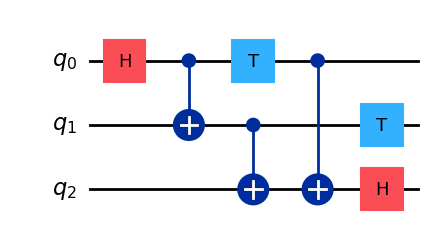

In [4]:
# Before we convert our new diagram back to a circuit, we should first check that it hasn't lost its circuit like property
# Lets make sure that the diagram can still be converted to a circuit using the following function
print("Can the diagram be converted into a circuit?")
print(integration.can_convert_to_circuit(new_diagram))

# Since the diagram is still circuit like, we can safely return back to the circuit representation
qc = integration.pyzx_to_qiskit(new_diagram)
qc.draw('mpl')

# Getting circuit metrics
This section shows how the following circuit metrics:  gate count, circuit depth, two qubit gate count, t gate count, and qubit count, are extracted and used to evaluate circuit performance.

In [5]:
from quantum_optimiser.multimetric import metrics # Import the metrics file
from quantum_optimiser.multimetric import metrics

# Compute metrics
qubit_count = metrics.circuit_qubit_count(qc)
gate_count = metrics.circuit_gate_count(qc)
two_qubit_count = metrics.circuit_two_qubit_gate_count(qc)
t_gate_count = metrics.circuit_t_gate_count(qc)
depth = metrics.circuit_depth(qc)

# Display results
print(f"Qubit count: {qubit_count}")
print(f"Gate count: {gate_count}")
print(f"Two-qubit gate count: {two_qubit_count}")
print(f"T gate count: {t_gate_count}")
print(f"Circuit depth: {depth}")

# Lets define a nice function to wrap around the metric functions

def get_circuit_metrics(circuit):
    """Return key circuit metrics as a dictionary."""
    return {
        "qubit_count": metrics.circuit_qubit_count(circuit),
        "gate_count": metrics.circuit_gate_count(circuit),
        "two_qubit_gate_count": metrics.circuit_two_qubit_gate_count(circuit),
        "t_gate_count": metrics.circuit_t_gate_count(circuit),
        "depth": metrics.circuit_depth(circuit)
    }

# Use the function
metrics_dict = get_circuit_metrics(qc)
metrics_dict

Qubit count: 3
Gate count: 7
Two-qubit gate count: 3
T gate count: 2
Circuit depth: 5


{'qubit_count': 3,
 'gate_count': 7,
 'two_qubit_gate_count': 3,
 't_gate_count': 2,
 'depth': 5}

# Designing a cost function
This section shows the prebuilt cost functions and how to use them, as well as how to constuct new ones

In [6]:
from quantum_optimiser.multimetric import loss

#There are four predefined loss functions, take a look at the file to see how they are constructed
naive = loss.naive_loss(qc)
informed = loss.informed_loss(qc)
log_weighted = loss.log_weighted_loss(qc)
quadratic = loss.quadratic_loss_circuit(qc)

loss_values = {
    "Naive loss": naive,
    "Informed loss": informed,
    "Log-weighted loss": log_weighted,
    "Quadratic loss": quadratic
}

loss_values

{'Naive loss': 4.000000000000001,
 'Informed loss': 3.3000000000000003,
 'Log-weighted loss': np.float64(30.48839129335635),
 'Quadratic loss': 2.145}

## Creating your own cost function
While the four functions serve as a starting point, you can also create your own custom function to guide the optimisation process.
The cost function simply needs to be a function of the circuit metrics. That is, it should take a circuit as input, compute its metrics, and return a single numerical value representing the cost of the circuit.

In [7]:
# Lets use the get_circuit_metrics we defined earlier to help us create a cost function

def custom_loss(circuit):
    m = get_circuit_metrics(circuit)
    return (
        0.2 * m["qubit_count"] + 
        0.4 * m["two_qubit_gate_count"] +
        0.1 * m["gate_count"] +
        0.2 * m["depth"] +
        0.1 * m["t_gate_count"]
    )

# Designing the hardware map
Some hardwares are limited by the number of qubits that can interact with each other, this section shows how to create a coupling map.
A hardware map specifies which pairs of physical qubits are allowed to interact directly. If a circuit contains a two-qubit gate between non-adjacent qubits, additional SWAP gates are required to make the circuit compatible with the hardware.

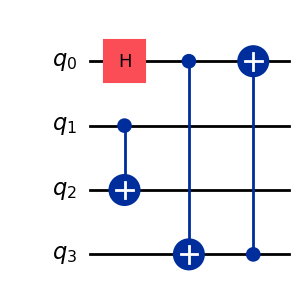

In [29]:
from quantum_optimiser.hardware_aware import hardware_map
# Lets define a very simple map consiting of four qubits in a line
line_hardware = hardware_map.hardware_map(
    4,
    [(0, 1), (1, 2), (2, 3)]
)

# Below lets define a circuit which violates the map we created

qc_hw = QuantumCircuit(4)
qc_hw.h(0)
qc_hw.cx(1, 2)   # legal
qc_hw.cx(0, 3)   # illegal on a line: qubits 0 and 3 are not adjacent
qc_hw.cx(3, 0)   # illegal on a line: qubits 0 and 3 are not adjacent

qc_hw.draw("mpl")



## Enforcing hardware constraints

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


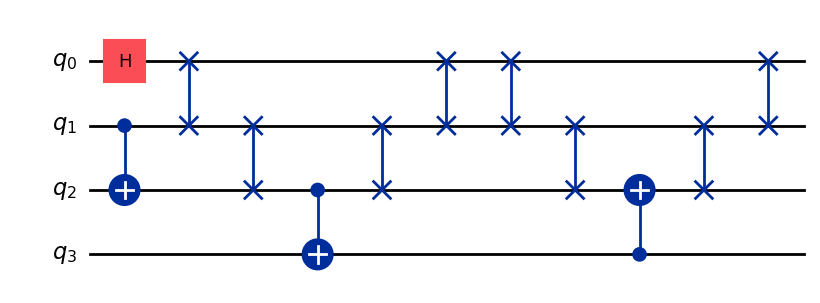

In [37]:
%load_ext autoreload
%autoreload 2
# Lets double check to see if this circuit is allowed on our hardware
line_hardware.is_compatible(qc_hw)

# Lets make it compatible to the hardware
compatible_qc = line_hardware.make_compatible(qc_hw)
compatible_qc.draw("mpl")
# We can now see that swaps have been applied to bring the cx gate on qubits that are adjacent

# Reducing the number of SWAP gates
Looking at the circuit above, we can see that to meet connectivity constraints, the function make_compatible has added some extra swap gates that are not needed, lets fix this by seeing if randomly permutating the qubits reduces the number of SWAP gates we need overall

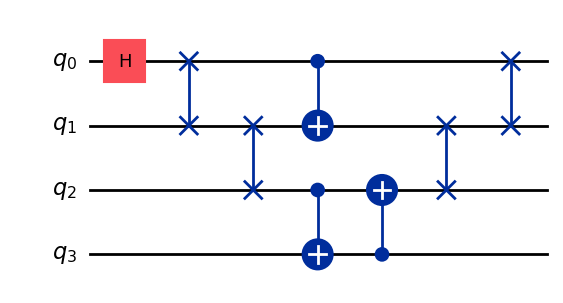

In [51]:
best = line_hardware.try_qubit_permutation(qc_hw)
best.draw("mpl")


# Running the optimiser
This section demonstrates how the optimiser is executed, including how candidate circuits are generated and evaluated, and how the optimisation process evolves towards improved solutions.

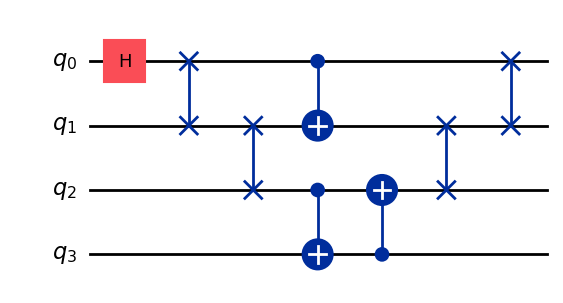

In [82]:
from quantum_optimiser.optimiser import simulated_annealing as anneal
from quantum_optimiser.multimetric import loss

# Choose a cost function and neighbour strategy
cost_function = loss.log_weighted_loss
neighbor_function = anneal.get_neighbor_weighted_rules

# Run the optimiser
best_circuit, best_diagram, best_cost, history = anneal.simulated_annealing_zx(
    circuit=qc_hw, # lets use the circuit defined earlier
    cost_function=cost_function,
    get_neighbor=neighbor_function,
    initial_temp=100.0, # Set the intial tempearture
    cooling_rate=0.95, # Set the cooling rate
    max_iterations=500, # Lets quit after 500 iterations
    min_temp=0.01, # Once we reach a temp of 0.01, we stop
    max_no_improvement=10, # If we have not found a better solution in 10 rounds, we start from the current best
    hardware=line_hardware # lets set the map to the hardware we defined
)

# Lets see what our optimised circuit looks like
best_circuit.draw("mpl")

In [83]:
#Lets compare the metrics to the original circuit after mapping it naively to the hardware
qc = line_hardware.make_compatible(qc_hw)
original_metrics = get_circuit_metrics(qc)
optimised_metrics = get_circuit_metrics(best_circuit)

print("Original circuit metrics:")
print(original_metrics)

print("\nOptimised circuit metrics:")
print(optimised_metrics)

Original circuit metrics:
{'qubit_count': 4, 'gate_count': 12, 'two_qubit_gate_count': 11, 't_gate_count': 0, 'depth': 11}

Optimised circuit metrics:
{'qubit_count': 4, 'gate_count': 8, 'two_qubit_gate_count': 7, 't_gate_count': 0, 'depth': 7}


## Example
As the demo circuit is quite small, there are limited improvements, to demonstrate the full potential of the optimiser, lets test it on a circuit full of identities

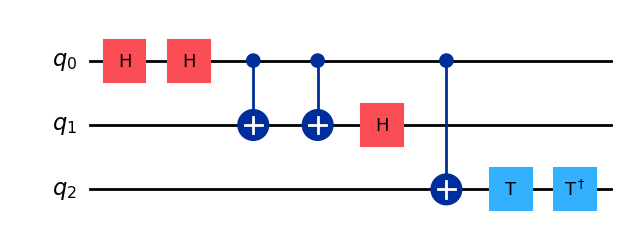

In [84]:
# Cancels: H followed by H
qc_demo = QuantumCircuit(3)

qc_demo.h(0)
qc_demo.h(0)

# Cancels: repeated CNOT on same pair
qc_demo.cx(0, 1)
qc_demo.cx(0, 1)

qc_demo.h(1)
qc_demo.cx(0,2)
# Cancels: T followed by Tdg
qc_demo.t(2)
qc_demo.tdg(2)
qc_demo.draw("mpl")


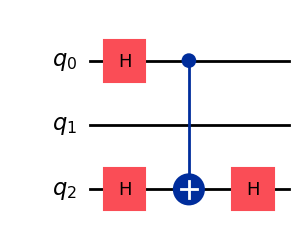

In [87]:
# Run the optimiser
best_circuit, best_diagram, best_cost, history = anneal.simulated_annealing_zx(
    circuit=qc_demo,
    cost_function=cost_function,
    get_neighbor=neighbor_function,
    initial_temp=100.0, 
    cooling_rate=0.95,
    max_iterations=200,
    min_temp=0.01,
    max_no_improvement=15, 
    hardware=None # When the map is set to none, the optimiser assumes there are no connections
)
best_circuit.draw("mpl")
